In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel('/content/Merged_Final_Dataset_With_Sentiment.xlsx',sheet_name='Sheet1')

In [ ]:
print(df.columns)

Index([' CompanyNumber', 'Google_Overall_Rating', 'Rating Rounded',
       'Google_Price_Level', 'Google_Review_Texts',
       'Google_Individual_Review_Ratings', 'CompanyName', 'RegAddress.CareOf',
       'RegAddress.AddressLine1', ' RegAddress.AddressLine2',
       'RegAddress.PostTown', 'RegAddress.County', 'RegAddress.Country',
       'RegAddress.PostCode', 'CompanyCategory', 'CompanyStatus',
       'Target Value', 'CountryOfOrigin', 'IncorporationDate',
       'Accounts.AccountRefDay', 'Accounts.AccountRefMonth',
       'Accounts.NextDueDate', 'Accounts.LastMadeUpDate',
       'Accounts.AccountCategory', 'Returns.NextDueDate',
       'Returns.LastMadeUpDate', 'Mortgages.NumMortCharges',
       'Mortgages.NumMortOutstanding', 'Mortgages.NumMortPartSatisfied',
       'Mortgages.NumMortSatisfied', 'SICCode.SicText_1', 'SICCode.SicText_2',
       'SICCode.SicText_3', 'SICCode.SicText_4',
       'LimitedPartnerships.NumGenPartners',
       'LimitedPartnerships.NumLimPartners', 'URI', '

In [ ]:
df = df.drop(['CompanyName','RegAddress.CareOf','RegAddress.AddressLine1',
              'RegAddress.PostTown','RegAddress.County','RegAddress.Country',
              ' RegAddress.AddressLine2','RegAddress.PostCode',
              'CompanyStatus','CountryOfOrigin',
              'LimitedPartnerships.NumGenPartners','LimitedPartnerships.NumLimPartners',
              'URI','PostCode_Validity_x','Potential_matches_name','Potential_matches_address',
              'Potential_matches_businessid','Final_Business_ID', 'Single_remove',
              'MatchScore','Match_Method', 'AddressLine1','AddressLine2',
              'AddressLine3', 'AddressLine4','BusinessTypeID','FHRSID', 'BusinessName',
              'Latitude','LocalAuthorityBusinessID', 'LocalAuthorityCode',
              'Longitude','RatingKey','RightToReply','PostCode_Validity_y'],axis=1)

In [ ]:
print(df.columns)

Index([' CompanyNumber', 'Google_Overall_Rating', 'Rating Rounded',
       'Google_Price_Level', 'Google_Review_Texts',
       'Google_Individual_Review_Ratings', 'CompanyCategory', 'Target Value',
       'IncorporationDate', 'Accounts.AccountRefDay',
       'Accounts.AccountRefMonth', 'Accounts.NextDueDate',
       'Accounts.LastMadeUpDate', 'Accounts.AccountCategory',
       'Returns.NextDueDate', 'Returns.LastMadeUpDate',
       'Mortgages.NumMortCharges', 'Mortgages.NumMortOutstanding',
       'Mortgages.NumMortPartSatisfied', 'Mortgages.NumMortSatisfied',
       'SICCode.SicText_1', 'SICCode.SicText_2', 'SICCode.SicText_3',
       'SICCode.SicText_4', 'PreviousName_1.CONDATE',
       ' PreviousName_1.CompanyName', ' PreviousName_2.CONDATE',
       ' PreviousName_2.CompanyName', 'PreviousName_3.CONDATE',
       ' PreviousName_3.CompanyName', 'PreviousName_4.CONDATE',
       ' PreviousName_4.CompanyName', 'PreviousName_5.CONDATE',
       ' PreviousName_5.CompanyName', 'PreviousName_

In [ ]:
df['Google_Review_Texts'] = df['Google_Review_Texts'].str.split('|')
df['Google_Individual_Review_Ratings'] = df['Google_Individual_Review_Ratings'].str.split('|')

In [ ]:
df.head()

,CompanyNumber,Google_Overall_Rating,Rating Rounded,Google_Price_Level,Google_Review_Texts,Google_Individual_Review_Ratings,CompanyCategory,Target Value,IncorporationDate,Accounts.AccountRefDay,...,SchemeType,Structural,Crime_per_postcode,Food and Beverage Quality,Customer Service,Delivery & Order Accuracy,Value for Money,Ambiance & Atmosphere,Cleanliness & Hygiene,Facilities & Amenities
0,00020100,4.6,5,NaN,[I’ve been to multiple meetings and events at ...,"[5 , 5 , 1 , 5 , 5]",Private Limited Company,0,1884-07-29,31,...,FHRS,0.0,0.096774,0.469057,0.398262,0.469636,0.784228,0.881146,0.271273,0.512164
1,00024166,3.8,4,NaN,[I have been a member in here for many years n...,"[5 , 5 , 1 , 5 , 5]",Private Limited Company,0,1887-03-26,31,...,FHRS,0.0,0.507042,0.658331,0.443740,0.410726,0.770613,0.770046,0.436467,0.699197
2,00024509,4.5,5,NaN,"[Lovely club, known for their great beer and d...","[5 , 5 , 4 , 4 , 5]",Private Limited Company,0,1887-06-01,31,...,FHRS,10.0,0.302326,0.752785,0.369531,0.287180,0.987385,0.799430,0.253940,0.396380
3,00066211,4.5,5,NaN,[We booked this venue for our wedding. It was ...,"[5 , 5 , 5 , 5 , 5]",Private Limited Company,0,1900-06-13,31,...,FHRS,5.0,0.200000,0.528596,0.749332,0.459355,0.974861,0.709116,0.339297,0.490483
4,00079244,4.4,4,NaN,[This is a fantastic venue. I had a party here...,"[5 , 5 , 5 , 4 , 5]",Private Limited Company,0,1903-11-25,30,...,FHRS,5.0,0.714286,0.553054,0.413038,0.390926,0.760123,0.872307,0.393583,0.531870


In [ ]:
df['Latest_Average'] = df['Google_Individual_Review_Ratings'].apply(lambda x: np.mean([int(i.strip()) for i in x]) if isinstance(x, list) else np.nan)

In [ ]:
df.head()

,CompanyNumber,Google_Overall_Rating,Rating Rounded,Google_Price_Level,Google_Review_Texts,Google_Individual_Review_Ratings,CompanyCategory,Target Value,IncorporationDate,Accounts.AccountRefDay,...,Structural,Crime_per_postcode,Food and Beverage Quality,Customer Service,Delivery & Order Accuracy,Value for Money,Ambiance & Atmosphere,Cleanliness & Hygiene,Facilities & Amenities,Latest_Average
0,00020100,4.6,5,NaN,[I’ve been to multiple meetings and events at ...,"[5 , 5 , 1 , 5 , 5]",Private Limited Company,0,1884-07-29,31,...,0.0,0.096774,0.469057,0.398262,0.469636,0.784228,0.881146,0.271273,0.512164,4.2
1,00024166,3.8,4,NaN,[I have been a member in here for many years n...,"[5 , 5 , 1 , 5 , 5]",Private Limited Company,0,1887-03-26,31,...,0.0,0.507042,0.658331,0.443740,0.410726,0.770613,0.770046,0.436467,0.699197,4.2
2,00024509,4.5,5,NaN,"[Lovely club, known for their great beer and d...","[5 , 5 , 4 , 4 , 5]",Private Limited Company,0,1887-06-01,31,...,10.0,0.302326,0.752785,0.369531,0.287180,0.987385,0.799430,0.253940,0.396380,4.6
3,00066211,4.5,5,NaN,[We booked this venue for our wedding. It was ...,"[5 , 5 , 5 , 5 , 5]",Private Limited Company,0,1900-06-13,31,...,5.0,0.200000,0.528596,0.749332,0.459355,0.974861,0.709116,0.339297,0.490483,5.0
4,00079244,4.4,4,NaN,[This is a fantastic venue. I had a party here...,"[5 , 5 , 5 , 4 , 5]",Private Limited Company,0,1903-11-25,30,...,5.0,0.714286,0.553054,0.413038,0.390926,0.760123,0.872307,0.393583,0.531870,4.8


In [ ]:
df.isna().sum()

,0
CompanyNumber,0
Google_Overall_Rating,0
Rating Rounded,0
Google_Price_Level,16245
Google_Review_Texts,126
...,...
Value for Money,184
Ambiance & Atmosphere,184
Cleanliness & Hygiene,184
Facilities & Amenities,184


In [ ]:
unique_counts = {}
for col in df.columns:
    try:
        unique_counts[col] = df[col].nunique()
    except TypeError:
        unique_counts[col] = 'Contains unhashable types (e.g., lists)' # Or np.nan

summary = pd.DataFrame({
    'Unique Values': pd.Series(unique_counts),
    'Data Type': df.dtypes
})

print(summary)

                                                  Unique Values Data Type
 CompanyNumber                                            24748    object
Google_Overall_Rating                                        40   float64
Rating Rounded                                                5     int64
Google_Price_Level                                            4   float64
Google_Review_Texts     Contains unhashable types (e.g., lists)    object
...                                                         ...       ...
Value for Money                                           24347   float64
Ambiance & Atmosphere                                     24405   float64
Cleanliness & Hygiene                                     24292   float64
Facilities & Amenities                                    24440   float64
Latest_Average                                               38   float64

[62 rows x 2 columns]


In [ ]:
# Identify columns that contain list-like objects and would cause TypeError with nunique()
cols_with_lists = [col for col, unique_val_summary in summary['Unique Values'].items() if unique_val_summary == 'Contains unhashable types (e.g., lists)']

# Get columns to evaluate for nunique() > 1, excluding list-containing columns
cols_to_evaluate_nunique = [col for col in df.columns if col not in cols_with_lists]

# Calculate nunique for these columns
nunique_series = df[cols_to_evaluate_nunique].nunique()

# Get columns to keep (those with more than 1 unique value)
cols_to_keep = nunique_series[nunique_series > 1].index.tolist()

# Add back the columns that contained lists (assuming they should always be kept if they are list columns)
cols_to_keep.extend(cols_with_lists)

# Filter the DataFrame
df = df[cols_to_keep]

In [ ]:
# 1. Identify columns with unhashable types (like lists)
unique_counts = {}
for col in df.columns:
    try:
        unique_counts[col] = df[col].nunique()
    except TypeError:
        unique_counts[col] = 'Contains unhashable types'

# 2. Create the summary to filter
summary = pd.DataFrame({
    'Unique Values': pd.Series(unique_counts),
    'Data Type': df.dtypes
})

In [ ]:
eligible_cols = summary[summary['Unique Values'] != 'Contains unhashable types'].index
binary_cols = []

for col in eligible_cols:
    # Only proceed if there are exactly 2 unique values
    if df[col].nunique() == 2:
        # Get the set of unique values
        vals = set(df[col].dropna().unique())

        # IGNORE if the values are already exactly {0, 1}
        if vals == {0, 1} or vals == {0.0, 1.0}:
            continue

        binary_cols.append(col)

# 4. Perform the encoding IN-PLACE
if binary_cols:
    df = pd.get_dummies(df, columns=binary_cols, drop_first=True, dtype=int)

print(f"Encoded {len(binary_cols)} columns: {binary_cols}")

Encoded 1 columns: ['SchemeType']


In [ ]:
unique_counts = {}
for col in df.columns:
    try:
        unique_counts[col] = df[col].nunique()
    except TypeError:
        unique_counts[col] = 'Contains unhashable types (e.g., lists)' # Or np.nan

summary = pd.DataFrame({
    'Unique Values': pd.Series(unique_counts),
    'Data Type': df.dtypes
})

print(summary)

                                                             Unique Values  \
 CompanyNumber                                                       24748   
Google_Overall_Rating                                                   40   
Rating Rounded                                                           5   
Google_Price_Level                                                       4   
CompanyCategory                                                          6   
Target Value                                                             2   
IncorporationDate                                                     4590   
Accounts.AccountRefDay                                                  31   
Accounts.AccountRefMonth                                                12   
Accounts.NextDueDate                                                   930   
Accounts.LastMadeUpDate                                                231   
Accounts.AccountCategory                                        

In [ ]:
df.head()

,CompanyNumber,Google_Overall_Rating,Rating Rounded,Google_Price_Level,CompanyCategory,Target Value,IncorporationDate,Accounts.AccountRefDay,Accounts.AccountRefMonth,Accounts.NextDueDate,...,Customer Service,Delivery & Order Accuracy,Value for Money,Ambiance & Atmosphere,Cleanliness & Hygiene,Facilities & Amenities,Latest_Average,Google_Review_Texts,Google_Individual_Review_Ratings,SchemeType_FHRS
0,00020100,4.6,5,NaN,Private Limited Company,0,1884-07-29,31,12,30/09/2026,...,0.398262,0.469636,0.784228,0.881146,0.271273,0.512164,4.2,[I’ve been to multiple meetings and events at ...,"[5 , 5 , 1 , 5 , 5]",1
1,00024166,3.8,4,NaN,Private Limited Company,0,1887-03-26,31,12,30/09/2026,...,0.443740,0.410726,0.770613,0.770046,0.436467,0.699197,4.2,[I have been a member in here for many years n...,"[5 , 5 , 1 , 5 , 5]",1
2,00024509,4.5,5,NaN,Private Limited Company,0,1887-06-01,31,10,31/07/2026,...,0.369531,0.287180,0.987385,0.799430,0.253940,0.396380,4.6,"[Lovely club, known for their great beer and d...","[5 , 5 , 4 , 4 , 5]",1
3,00066211,4.5,5,NaN,Private Limited Company,0,1900-06-13,31,8,31/05/2026,...,0.749332,0.459355,0.974861,0.709116,0.339297,0.490483,5.0,[We booked this venue for our wedding. It was ...,"[5 , 5 , 5 , 5 , 5]",1
4,00079244,4.4,4,NaN,Private Limited Company,0,1903-11-25,30,9,30/06/2026,...,0.413038,0.390926,0.760123,0.872307,0.393583,0.531870,4.8,[This is a fantastic venue. I had a party here...,"[5 , 5 , 5 , 4 , 5]",1


In [ ]:
print(*df.columns, sep='\n')

 CompanyNumber
Google_Overall_Rating
Rating Rounded
Google_Price_Level
CompanyCategory
Target Value
IncorporationDate
Accounts.AccountRefDay
Accounts.AccountRefMonth
Accounts.NextDueDate
Accounts.LastMadeUpDate
Accounts.AccountCategory
Returns.NextDueDate
Returns.LastMadeUpDate
Mortgages.NumMortCharges
Mortgages.NumMortOutstanding
Mortgages.NumMortSatisfied
SICCode.SicText_1
SICCode.SicText_2
SICCode.SicText_3
SICCode.SicText_4
PreviousName_1.CONDATE
 PreviousName_1.CompanyName
 PreviousName_2.CONDATE
 PreviousName_2.CompanyName
PreviousName_3.CONDATE
 PreviousName_3.CompanyName
PreviousName_4.CONDATE
 PreviousName_4.CompanyName
ConfStmtNextDueDate
 ConfStmtLastMadeUpDate
Number of restaurants based on CH
Potential_Ownership_Change
BusinessType
ConfidenceInManagement
Hygiene
LocalAuthorityName
NewRatingPending
PostCode
Number of restaurants in Postcode
RatingDate
RatingValue
Structural
Crime_per_postcode
Food and Beverage Quality
Customer Service
Delivery & Order Accuracy
Value for Mon

In [ ]:
df = pd.get_dummies(df,columns = ['CompanyCategory','Accounts.AccountCategory',
                                  'SICCode.SicText_1','BusinessType'],dummy_na=True,dtype = int)

In [ ]:
df

,CompanyNumber,Google_Overall_Rating,Rating Rounded,Google_Price_Level,Target Value,IncorporationDate,Accounts.AccountRefDay,Accounts.AccountRefMonth,Accounts.NextDueDate,Accounts.LastMadeUpDate,...,BusinessType_Manufacturers/packers,BusinessType_Mobile caterer,BusinessType_Other catering premises,BusinessType_Pub/bar/nightclub,BusinessType_Restaurant/Cafe/Canteen,BusinessType_Retailers - other,BusinessType_Retailers - supermarkets/hypermarkets,BusinessType_School/college/university,BusinessType_Takeaway/sandwich shop,BusinessType_nan
0,00020100,4.6,5,NaN,0,1884-07-29,31,12,30/09/2026,31/12/2024,...,0,0,0,1,0,0,0,0,0,0
1,00024166,3.8,4,NaN,0,1887-03-26,31,12,30/09/2026,31/12/2024,...,0,0,0,1,0,0,0,0,0,0
2,00024509,4.5,5,NaN,0,1887-06-01,31,10,31/07/2026,31/10/2024,...,0,0,0,1,0,0,0,0,0,0
3,00066211,4.5,5,NaN,0,1900-06-13,31,8,31/05/2026,31/08/2024,...,0,0,0,1,0,0,0,0,0,0
4,00079244,4.4,4,NaN,0,1903-11-25,30,9,30/06/2026,30/09/2024,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24743,17000396,4.5,5,NaN,0,2026-01-30,31,1,30/10/2027,NaN,...,0,0,1,0,0,0,0,0,0,0
24744,17003744,4.8,5,NaN,0,2026-01-30,31,1,30/10/2027,NaN,...,0,0,0,0,1,0,0,0,0,0
24745,17004755,4.6,5,NaN,0,2026-01-31,31,1,31/10/2027,NaN,...,0,0,0,0,0,1,0,0,0,0
24746,17005241,4.7,5,NaN,0,2026-01-31,31,1,31/10/2027,NaN,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
unique_counts = {}
for col in df.columns:
    try:
        unique_counts[col] = df[col].nunique()
    except TypeError:
        unique_counts[col] = 'Contains unhashable types (e.g., lists)' # Or np.nan

summary = pd.DataFrame({
    'Unique Values': pd.Series(unique_counts),
    'Data Type': df.dtypes
})

print(summary)

                                                   Unique Values Data Type
 CompanyNumber                                             24748    object
Google_Overall_Rating                                         40   float64
Rating Rounded                                                 5     int64
Google_Price_Level                                             4   float64
Target Value                                                   2     int64
...                                                          ...       ...
BusinessType_Retailers - other                                 2     int64
BusinessType_Retailers - supermarkets/hypermarkets             2     int64
BusinessType_School/college/university                         2     int64
BusinessType_Takeaway/sandwich shop                            2     int64
BusinessType_nan                                               1     int64

[93 rows x 2 columns]


In [ ]:
df.head()

,CompanyNumber,Google_Overall_Rating,Rating Rounded,Google_Price_Level,Target Value,IncorporationDate,Accounts.AccountRefDay,Accounts.AccountRefMonth,Accounts.NextDueDate,Accounts.LastMadeUpDate,...,BusinessType_Manufacturers/packers,BusinessType_Mobile caterer,BusinessType_Other catering premises,BusinessType_Pub/bar/nightclub,BusinessType_Restaurant/Cafe/Canteen,BusinessType_Retailers - other,BusinessType_Retailers - supermarkets/hypermarkets,BusinessType_School/college/university,BusinessType_Takeaway/sandwich shop,BusinessType_nan
0,00020100,4.6,5,NaN,0,1884-07-29,31,12,30/09/2026,31/12/2024,...,0,0,0,1,0,0,0,0,0,0
1,00024166,3.8,4,NaN,0,1887-03-26,31,12,30/09/2026,31/12/2024,...,0,0,0,1,0,0,0,0,0,0
2,00024509,4.5,5,NaN,0,1887-06-01,31,10,31/07/2026,31/10/2024,...,0,0,0,1,0,0,0,0,0,0
3,00066211,4.5,5,NaN,0,1900-06-13,31,8,31/05/2026,31/08/2024,...,0,0,0,1,0,0,0,0,0,0
4,00079244,4.4,4,NaN,0,1903-11-25,30,9,30/06/2026,30/09/2024,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
print(*df.columns, sep='\n')

 CompanyNumber
Google_Overall_Rating
Rating Rounded
Google_Price_Level
Target Value
IncorporationDate
Accounts.AccountRefDay
Accounts.AccountRefMonth
Accounts.NextDueDate
Accounts.LastMadeUpDate
Returns.NextDueDate
Returns.LastMadeUpDate
Mortgages.NumMortCharges
Mortgages.NumMortOutstanding
Mortgages.NumMortSatisfied
SICCode.SicText_2
SICCode.SicText_3
SICCode.SicText_4
PreviousName_1.CONDATE
 PreviousName_1.CompanyName
 PreviousName_2.CONDATE
 PreviousName_2.CompanyName
PreviousName_3.CONDATE
 PreviousName_3.CompanyName
PreviousName_4.CONDATE
 PreviousName_4.CompanyName
ConfStmtNextDueDate
 ConfStmtLastMadeUpDate
Number of restaurants based on CH
Potential_Ownership_Change
ConfidenceInManagement
Hygiene
LocalAuthorityName
NewRatingPending
PostCode
Number of restaurants in Postcode
RatingDate
RatingValue
Structural
Crime_per_postcode
Food and Beverage Quality
Customer Service
Delivery & Order Accuracy
Value for Money
Ambiance & Atmosphere
Cleanliness & Hygiene
Facilities & Amenities
La

In [ ]:
# Identify columns that contain list-like objects and would cause TypeError with nunique()
cols_with_lists = [col for col, unique_val_summary in summary['Unique Values'].items() if unique_val_summary == 'Contains unhashable types (e.g., lists)']

# Get columns to evaluate for nunique() > 1, excluding list-containing columns
cols_to_evaluate_nunique = [col for col in df.columns if col not in cols_with_lists]

# Calculate nunique for these columns
nunique_series = df[cols_to_evaluate_nunique].nunique()

# Get columns to keep (those with more than 1 unique value)
cols_to_keep = nunique_series[nunique_series > 1].index.tolist()

# Add back the columns that contained lists (assuming they should always be kept if they are list columns)
cols_to_keep.extend(cols_with_lists)

# Filter the DataFrame
df = df[cols_to_keep]

In [ ]:
unique_counts = {}
for col in df.columns:
    try:
        unique_counts[col] = df[col].nunique()
    except TypeError:
        unique_counts[col] = 'Contains unhashable types (e.g., lists)' # Or np.nan

summary = pd.DataFrame({
    'Unique Values': pd.Series(unique_counts),
    'Data Type': df.dtypes
})

print(summary)

                                                                              Unique Values  \
 CompanyNumber                                                                        24748   
Google_Overall_Rating                                                                    40   
Rating Rounded                                                                            5   
Google_Price_Level                                                                        4   
Target Value                                                                              2   
...                                                                                     ...   
BusinessType_Retailers - supermarkets/hypermarkets                                        2   
BusinessType_School/college/university                                                    2   
BusinessType_Takeaway/sandwich shop                                                       2   
Google_Review_Texts                               

In [ ]:
print(*df.columns, sep='\n')

 CompanyNumber
Google_Overall_Rating
Rating Rounded
Google_Price_Level
Target Value
IncorporationDate
Accounts.AccountRefDay
Accounts.AccountRefMonth
Accounts.NextDueDate
Accounts.LastMadeUpDate
Returns.NextDueDate
Returns.LastMadeUpDate
Mortgages.NumMortCharges
Mortgages.NumMortOutstanding
Mortgages.NumMortSatisfied
SICCode.SicText_2
SICCode.SicText_3
SICCode.SicText_4
PreviousName_1.CONDATE
 PreviousName_1.CompanyName
 PreviousName_2.CONDATE
 PreviousName_2.CompanyName
PreviousName_3.CONDATE
 PreviousName_3.CompanyName
PreviousName_4.CONDATE
 PreviousName_4.CompanyName
ConfStmtNextDueDate
 ConfStmtLastMadeUpDate
Number of restaurants based on CH
Potential_Ownership_Change
ConfidenceInManagement
Hygiene
LocalAuthorityName
NewRatingPending
PostCode
Number of restaurants in Postcode
RatingDate
RatingValue
Structural
Crime_per_postcode
Food and Beverage Quality
Customer Service
Delivery & Order Accuracy
Value for Money
Ambiance & Atmosphere
Cleanliness & Hygiene
Facilities & Amenities
La

In [ ]:
name_cols = [col for col in df.columns if '.CompanyName' in col]
df['Total_Previous_Names'] = df[name_cols].notna().sum(axis=1)
df[['Total_Previous_Names'] + name_cols].head()

/tmp/ipykernel_15315/3465923185.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total_Previous_Names'] = df[name_cols].notna().sum(axis=1)


,Total_Previous_Names,PreviousName_1.CompanyName,PreviousName_2.CompanyName,PreviousName_3.CompanyName,PreviousName_4.CompanyName
0,0,NaN,NaN,NaN,NaN
1,0,NaN,NaN,NaN,NaN
2,1,"MIRFIELD LIBERAL CLUB BUILDINGS COMPANY,LIMITE...",NaN,NaN,NaN
3,0,NaN,NaN,NaN,NaN
4,0,NaN,NaN,NaN,NaN


In [ ]:
df = df.drop(name_cols,axis=1)

In [ ]:
len(df.columns)

86

In [ ]:
name_cols = ['SICCode.SicText_2','SICCode.SicText_3','SICCode.SicText_4']
df['Total_Other_Codes'] = df[name_cols].notna().sum(axis=1)
df[['Total_Other_Codes'] + name_cols].head()

,Total_Other_Codes,SICCode.SicText_2,SICCode.SicText_3,SICCode.SicText_4
0,0,NaN,NaN,NaN
1,0,NaN,NaN,NaN
2,0,NaN,NaN,NaN
3,1,93120 - Activities of sport clubs,NaN,NaN
4,0,NaN,NaN,NaN


In [ ]:
df = df.drop(name_cols,axis=1)

In [ ]:
len(df.columns)

84

In [ ]:
print(*df.columns, sep='\n')

 CompanyNumber
Google_Overall_Rating
Rating Rounded
Google_Price_Level
Target Value
IncorporationDate
Accounts.AccountRefDay
Accounts.AccountRefMonth
Accounts.NextDueDate
Accounts.LastMadeUpDate
Returns.NextDueDate
Returns.LastMadeUpDate
Mortgages.NumMortCharges
Mortgages.NumMortOutstanding
Mortgages.NumMortSatisfied
PreviousName_1.CONDATE
 PreviousName_2.CONDATE
PreviousName_3.CONDATE
PreviousName_4.CONDATE
ConfStmtNextDueDate
 ConfStmtLastMadeUpDate
Number of restaurants based on CH
Potential_Ownership_Change
ConfidenceInManagement
Hygiene
LocalAuthorityName
NewRatingPending
PostCode
Number of restaurants in Postcode
RatingDate
RatingValue
Structural
Crime_per_postcode
Food and Beverage Quality
Customer Service
Delivery & Order Accuracy
Value for Money
Ambiance & Atmosphere
Cleanliness & Hygiene
Facilities & Amenities
Latest_Average
SchemeType_FHRS
CompanyCategory_Community Interest Company
CompanyCategory_PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited'

In [ ]:
from datetime import date
today = date(2026, 3, 9)

In [ ]:
REFERENCE_DATE = pd.Timestamp('2026-03-09')
df['Months_Since_Incorp'] = (
    (REFERENCE_DATE.year - df['IncorporationDate'].dt.year) * 12 +
    (REFERENCE_DATE.month - df['IncorporationDate'].dt.month)
)

In [ ]:
df['Months_Since_Incorp'].isna().sum()

np.int64(0)

In [ ]:
REF_DATE = pd.Timestamp('2026-03-09')

# 1. Ensure all date columns are datetime
date_cols = ['IncorporationDate'] + [col for col in df.columns if '.CONDATE' in col]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

def calculate_avg_months(row):
    # Gather all valid dates for this specific row and sort them
    events = sorted([row[d] for d in date_cols if pd.notna(row[d])])

    # CASE 1: No name changes (Only IncorporationDate exists)
    if len(events) == 1:
        # Calculate months from Incorporation to Today (The 'Ongoing' period)
        total_months = ((REF_DATE.year - events[0].year) * 12 + (REF_DATE.month - events[0].month))
        return total_months

    # CASE 2: Name changes exist
    # Calculate differences between consecutive events in months
    intervals = []
    for i in range(len(events) - 1):
        diff = ((events[i+1].year - events[i].year) * 12 + (events[i+1].month - events[i].month))
        intervals.append(diff)

    # Return the average of the intervals
    return sum(intervals) / len(intervals)

df['Avg_Change_Interval'] = df.apply(calculate_avg_months, axis=1)

In [ ]:
def get_interval_category(val):
    if pd.isna(val): return 'Unknown'
    if val <= 12:    return 'Frequent_Changes'  # Avg change every year or less
    if val <= 48:    return 'Moderate_Stability' # Avg change every 1-4 years
    return 'High_Stability_Ongoing'             # Avg change every 4+ years (or never)

df['Tenure_Category'] = df['Avg_Change_Interval'].apply(get_interval_category)
df[['Tenure_Category','Target Value']].to_excel('Tenure_Pivot_Data.xlsx',index = False)

# 3. Final Step: One-Hot Encode (Dummy values)
df = pd.get_dummies(df, columns=['Tenure_Category'], dtype=int)

In [ ]:
df.head()

,CompanyNumber,Google_Overall_Rating,Rating Rounded,Google_Price_Level,Target Value,IncorporationDate,Accounts.AccountRefDay,Accounts.AccountRefMonth,Accounts.NextDueDate,Accounts.LastMadeUpDate,...,BusinessType_Takeaway/sandwich shop,Google_Review_Texts,Google_Individual_Review_Ratings,Total_Previous_Names,Total_Other_Codes,Months_Since_Incorp,Avg_Change_Interval,Tenure_Category_Frequent_Changes,Tenure_Category_High_Stability_Ongoing,Tenure_Category_Moderate_Stability
0,00020100,4.6,5,NaN,0,1884-07-29,31,12,30/09/2026,31/12/2024,...,0,[I’ve been to multiple meetings and events at ...,"[5 , 5 , 1 , 5 , 5]",0,0,1700,1700.0,0,1,0
1,00024166,3.8,4,NaN,0,1887-03-26,31,12,30/09/2026,31/12/2024,...,0,[I have been a member in here for many years n...,"[5 , 5 , 1 , 5 , 5]",0,0,1668,1668.0,0,1,0
2,00024509,4.5,5,NaN,0,1887-06-01,31,10,31/07/2026,31/10/2024,...,0,"[Lovely club, known for their great beer and d...","[5 , 5 , 4 , 4 , 5]",1,0,1665,1617.0,0,1,0
3,00066211,4.5,5,NaN,0,1900-06-13,31,8,31/05/2026,31/08/2024,...,0,[We booked this venue for our wedding. It was ...,"[5 , 5 , 5 , 5 , 5]",0,1,1509,1509.0,0,1,0
4,00079244,4.4,4,NaN,0,1903-11-25,30,9,30/06/2026,30/09/2024,...,0,[This is a fantastic venue. I had a party here...,"[5 , 5 , 5 , 4 , 5]",0,0,1468,1468.0,0,1,0


In [ ]:
print(*df.columns, sep='\n')

 CompanyNumber
Google_Overall_Rating
Rating Rounded
Google_Price_Level
Target Value
IncorporationDate
Accounts.AccountRefDay
Accounts.AccountRefMonth
Accounts.NextDueDate
Accounts.LastMadeUpDate
Returns.NextDueDate
Returns.LastMadeUpDate
Mortgages.NumMortCharges
Mortgages.NumMortOutstanding
Mortgages.NumMortSatisfied
PreviousName_1.CONDATE
 PreviousName_2.CONDATE
PreviousName_3.CONDATE
PreviousName_4.CONDATE
ConfStmtNextDueDate
 ConfStmtLastMadeUpDate
Number of restaurants based on CH
Potential_Ownership_Change
ConfidenceInManagement
Hygiene
LocalAuthorityName
NewRatingPending
PostCode
Number of restaurants in Postcode
RatingDate
RatingValue
Structural
Crime_per_postcode
Food and Beverage Quality
Customer Service
Delivery & Order Accuracy
Value for Money
Ambiance & Atmosphere
Cleanliness & Hygiene
Facilities & Amenities
Latest_Average
SchemeType_FHRS
CompanyCategory_Community Interest Company
CompanyCategory_PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited'

In [ ]:
df = df.drop(['PreviousName_1.CONDATE',' PreviousName_2.CONDATE','PreviousName_3.CONDATE','PreviousName_4.CONDATE','Avg_Change_Interval','Rating Rounded'],axis=1)

In [ ]:
print(*df.columns, sep='\n')

 CompanyNumber
Google_Overall_Rating
Google_Price_Level
Target Value
IncorporationDate
Accounts.AccountRefDay
Accounts.AccountRefMonth
Accounts.NextDueDate
Accounts.LastMadeUpDate
Returns.NextDueDate
Returns.LastMadeUpDate
Mortgages.NumMortCharges
Mortgages.NumMortOutstanding
Mortgages.NumMortSatisfied
ConfStmtNextDueDate
 ConfStmtLastMadeUpDate
Number of restaurants based on CH
Potential_Ownership_Change
ConfidenceInManagement
Hygiene
LocalAuthorityName
NewRatingPending
PostCode
Number of restaurants in Postcode
RatingDate
RatingValue
Structural
Crime_per_postcode
Food and Beverage Quality
Customer Service
Delivery & Order Accuracy
Value for Money
Ambiance & Atmosphere
Cleanliness & Hygiene
Facilities & Amenities
Latest_Average
SchemeType_FHRS
CompanyCategory_Community Interest Company
CompanyCategory_PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)
CompanyCategory_PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)
CompanyCat

In [ ]:
date_cols = ['ConfStmtNextDueDate', ' ConfStmtLastMadeUpDate']

# Convert them to datetime
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

In [ ]:
# Using our fixed constant: March 9, 2026
df['Is_Filing_Overdue'] = (df['ConfStmtNextDueDate'] < REF_DATE).astype(int)

In [ ]:
df = df.drop(date_cols,axis=1)
df = df.drop(['IncorporationDate'],axis =1)

In [ ]:
print(*df.columns, sep='\n')

 CompanyNumber
Google_Overall_Rating
Google_Price_Level
Target Value
Accounts.AccountRefDay
Accounts.AccountRefMonth
Accounts.NextDueDate
Accounts.LastMadeUpDate
Returns.NextDueDate
Returns.LastMadeUpDate
Mortgages.NumMortCharges
Mortgages.NumMortOutstanding
Mortgages.NumMortSatisfied
Number of restaurants based on CH
Potential_Ownership_Change
ConfidenceInManagement
Hygiene
LocalAuthorityName
NewRatingPending
PostCode
Number of restaurants in Postcode
RatingDate
RatingValue
Structural
Crime_per_postcode
Food and Beverage Quality
Customer Service
Delivery & Order Accuracy
Value for Money
Ambiance & Atmosphere
Cleanliness & Hygiene
Facilities & Amenities
Latest_Average
SchemeType_FHRS
CompanyCategory_Community Interest Company
CompanyCategory_PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)
CompanyCategory_PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)
CompanyCategory_Private Limited Company
CompanyCategory_Private Unlimite

In [ ]:
financial_date_cols = ['Accounts.NextDueDate', 'Accounts.LastMadeUpDate']

for col in financial_date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Check if accounts are overdue as of today (March 9, 2026)
df['Accounts_Overdue'] = (df['Accounts.NextDueDate'] < pd.Timestamp('2026-03-09')).astype(int)

/tmp/ipykernel_15315/2816308338.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_15315/2816308338.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [ ]:
df = df.drop(financial_date_cols,axis = 1)

In [ ]:
print(*df.columns, sep='\n')

 CompanyNumber
Google_Overall_Rating
Google_Price_Level
Target Value
Accounts.AccountRefDay
Accounts.AccountRefMonth
Returns.NextDueDate
Returns.LastMadeUpDate
Mortgages.NumMortCharges
Mortgages.NumMortOutstanding
Mortgages.NumMortSatisfied
Number of restaurants based on CH
Potential_Ownership_Change
ConfidenceInManagement
Hygiene
LocalAuthorityName
NewRatingPending
PostCode
Number of restaurants in Postcode
RatingDate
RatingValue
Structural
Crime_per_postcode
Food and Beverage Quality
Customer Service
Delivery & Order Accuracy
Value for Money
Ambiance & Atmosphere
Cleanliness & Hygiene
Facilities & Amenities
Latest_Average
SchemeType_FHRS
CompanyCategory_Community Interest Company
CompanyCategory_PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)
CompanyCategory_PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)
CompanyCategory_Private Limited Company
CompanyCategory_Private Unlimited Company
CompanyCategory_Public Limited Comp

In [ ]:
df = df.drop(['Accounts.AccountRefDay','Accounts.AccountRefMonth'],axis=1)

In [ ]:
df = df.drop(['Returns.NextDueDate','Returns.LastMadeUpDate'],axis =1)

In [ ]:
print(*df.columns, sep='\n')

 CompanyNumber
Google_Overall_Rating
Google_Price_Level
Target Value
Mortgages.NumMortCharges
Mortgages.NumMortOutstanding
Mortgages.NumMortSatisfied
Number of restaurants based on CH
Potential_Ownership_Change
ConfidenceInManagement
Hygiene
LocalAuthorityName
NewRatingPending
PostCode
Number of restaurants in Postcode
RatingDate
RatingValue
Structural
Crime_per_postcode
Food and Beverage Quality
Customer Service
Delivery & Order Accuracy
Value for Money
Ambiance & Atmosphere
Cleanliness & Hygiene
Facilities & Amenities
Latest_Average
SchemeType_FHRS
CompanyCategory_Community Interest Company
CompanyCategory_PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)
CompanyCategory_PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)
CompanyCategory_Private Limited Company
CompanyCategory_Private Unlimited Company
CompanyCategory_Public Limited Company
Accounts.AccountCategory_AUDIT EXEMPTION SUBSIDIARY
Accounts.AccountCategory_DORMANT
Ac

In [ ]:
df = df.drop(['LocalAuthorityName'],axis =1)

In [ ]:
max(df['Months_Since_Incorp'])

1700

In [ ]:
df['Months_Since_Incorp'].describe()

,Months_Since_Incorp
count,24748.000000
mean,54.546266
std,70.496672
min,2.000000
25%,14.000000
50%,32.000000
75%,75.000000
max,1700.000000


In [ ]:
missing_data = df.isna().sum()
print(missing_data[missing_data > 0])

Google_Price_Level                  16245
ConfidenceInManagement               3708
Hygiene                              3708
RatingDate                           1726
Structural                           3708
Crime_per_postcode                   3280
Food and Beverage Quality             184
Customer Service                      184
Delivery & Order Accuracy             184
Value for Money                       184
Ambiance & Atmosphere                 184
Cleanliness & Hygiene                 184
Facilities & Amenities                184
Latest_Average                         12
Google_Review_Texts                   126
Google_Individual_Review_Ratings       12
dtype: int64


In [ ]:
df = df.drop(['Google_Individual_Review_Ratings','Google_Review_Texts','RatingDate','PostCode'],axis = 1)

In [ ]:
non_numeric_cols = df.select_dtypes(exclude=['number'])

# Print the names and their specific dtypes
print(non_numeric_cols.dtypes)

 CompanyNumber                object
Potential_Ownership_Change      bool
NewRatingPending                bool
RatingValue                   object
dtype: object


In [ ]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df['RatingValue'].value_counts()

,count
RatingValue,
5,12497
4,4801
3,3139
AwaitingInspection,1708
Pass,1001
2,688
1,554
Improvement Required,157
0,107


In [ ]:
rating_map = {
    '5': 5, '4': 4, '3': 3, '2': 2, '1': 1, '0': 0,
    'Pass': 4,                    # "Pass" is the top tier in Scotland
    'Pass and Eat Safe': 5,       # Extra top tier
    'Improvement Required': 1,    # Usually equivalent to a 1 or 0
    'AwaitingInspection': np.nan, # We don't know yet (KNN will fill this!)
    'AwaitingPublication': np.nan,
    'Exempt': np.nan              # Exempt is not a score
}

df['RatingValue'] = df['RatingValue'].map(rating_map)

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# 1. Isolate the ID and Target (Keep them on the sidelines)
# We only want to impute the features (X)
id_series = df[' CompanyNumber']
target_series = df['Target Value'] # Or whatever your target name is
features = df.drop(columns=[' CompanyNumber', 'Target Value'])

# 2. Filter for Numeric only (KNN cannot handle 'Object' or 'Datetime')
X_numeric = features.select_dtypes(include=[np.number])
X_unused = features.select_dtypes(exclude=[np.number]) # Save these to reattach later

# 3. Scale the Data (KNN requires 0-1 range to work fairly)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_numeric)

# 4. Run the KNN Imputer
# n_neighbors=5 looks at the 5 most similar businesses to fill a blank
imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed_array = imputer.fit_transform(X_scaled)

# 5. Reverse the Scaling & Rebuild DataFrame
X_final = pd.DataFrame(
    scaler.inverse_transform(X_imputed_array),
    columns=X_numeric.columns,
    index=df.index # Keep original row order
)

# 6. Reattach IDs and Target
X_final[' CompanyNumber'] = id_series
X_final['Target Value'] = target_series

print("Imputation complete. No more NaNs in numeric columns.")

Imputation complete. No more NaNs in numeric columns.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define X (Features) and y (Target)
# We drop ID and Target from X so the model doesn't 'cheat'
X = X_final.drop(columns=[' CompanyNumber', 'Target Value'])
y = X_final['Target Value']
ids = X_final[' CompanyNumber']

# 2. Split into Training (80%) and Testing (20%)
# Passing 'ids' into the split keeps them synchronized with the rows
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, ids, test_size=0.2, random_state=42, stratify=y
)

# 3. Initialize and Train the Model
# 'max_iter=1000' ensures the math has enough time to 'converge' for 77 columns
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)

# 4. Predict Outcomes and Probabilities
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1] # Probability of being 'Target=1'

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score, roc_auc_score)

def evaluate_model(model, X_train, y_train, X_test, y_test, name="Model"):
    # 1. Generate predictions and probabilities for both sets
    train_probs = model.predict_proba(X_train)[:, 1]
    test_preds = model.predict(X_test)
    test_probs = model.predict_proba(X_test)[:, 1]

    # 2. Calculate scores
    train_auc = roc_auc_score(y_train, train_probs)
    test_auc = roc_auc_score(y_test, test_probs)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, test_preds)

    # 3. Print numeric summaries
    print(f"--- {name} Fit Analysis ---")
    print(f"TRAIN: Accuracy = {train_acc:.2%}, ROC-AUC = {train_auc:.4f}")
    print(f"TEST:  Accuracy = {test_acc:.2%}, ROC-AUC = {test_auc:.4f}")
    print(f"OVERFIT GAP (AUC): {train_auc - test_auc:.4f}")

    print("\nTest Set Classification Report:")
    print(classification_report(y_test, test_preds))

    # 4. Setup Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix (Test Set)
    cm = confusion_matrix(y_test, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
    ax1.set_title(f'Confusion Matrix (Test): {name}')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')

    # ROC Curve (Test Set)
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Test ROC (area = {test_auc:.2f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_title(f'ROC Curve (Test): {name}')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# To call the function:
# evaluate_model(model, X_train, y_train, X_test, y_test, name="LogReg Baseline")

--- Unweighted Baseline Fit Analysis ---
TRAIN: Accuracy = 96.96%, ROC-AUC = 0.9176
TEST:  Accuracy = 97.09%, ROC-AUC = 0.9302
OVERFIT GAP (AUC): -0.0127

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4705
           1       0.79      0.56      0.66       245

    accuracy                           0.97      4950
   macro avg       0.88      0.78      0.82      4950
weighted avg       0.97      0.97      0.97      4950



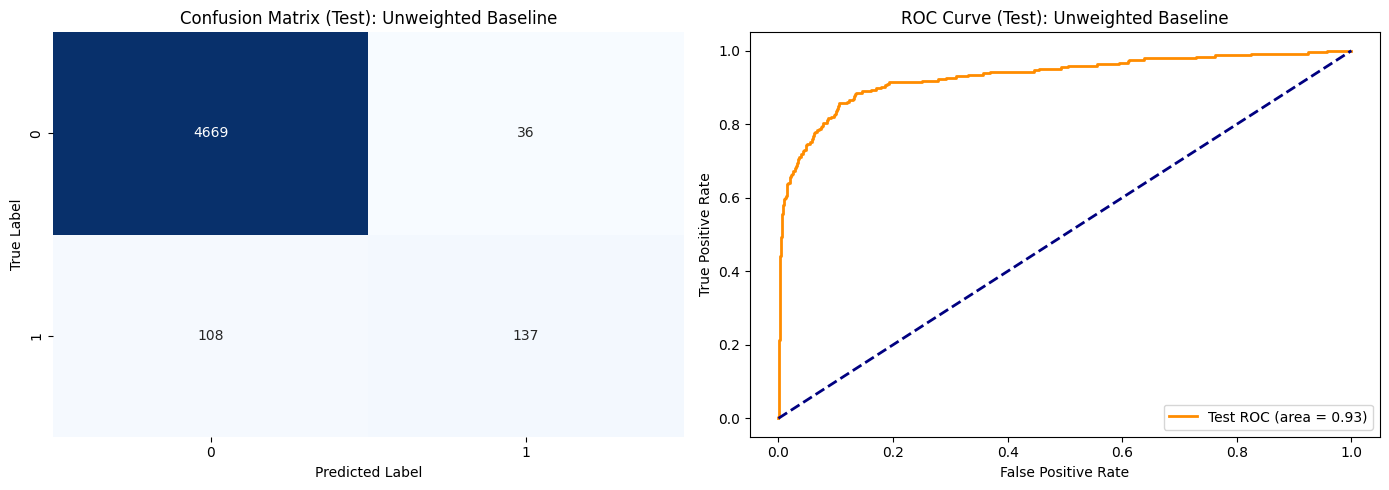

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Class-Weighted Model Fit Analysis ---
TRAIN: Accuracy = 84.54%, ROC-AUC = 0.9218
TEST:  Accuracy = 85.54%, ROC-AUC = 0.9291
OVERFIT GAP (AUC): -0.0073

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      4705
           1       0.24      0.87      0.37       245

    accuracy                           0.86      4950
   macro avg       0.62      0.86      0.65      4950
weighted avg       0.96      0.86      0.89      4950



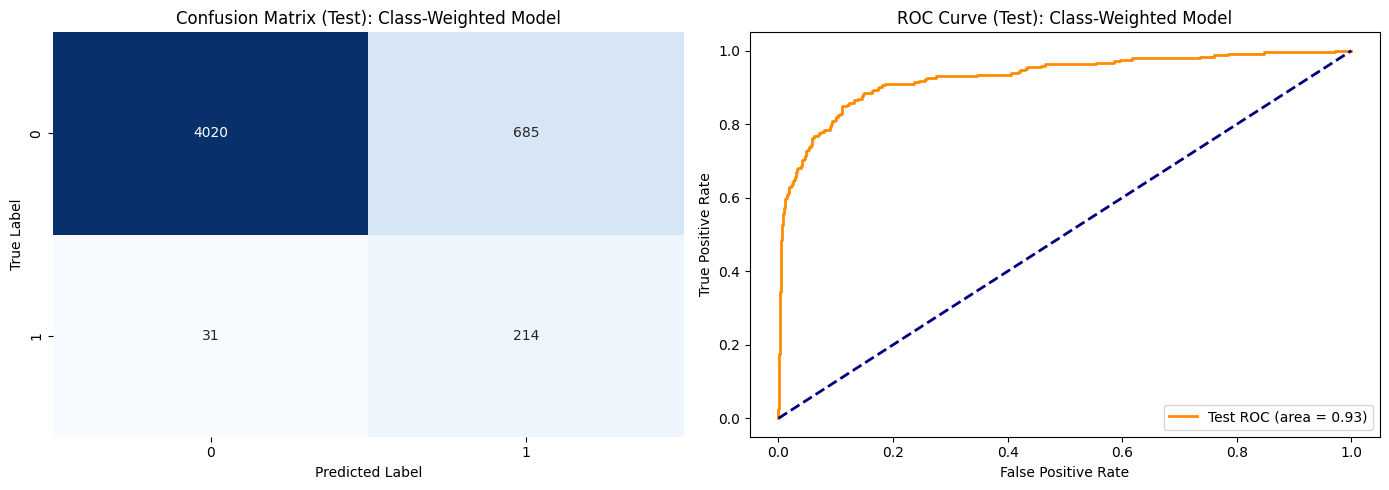

In [ ]:
# 1. Re-run your standard model
evaluate_model(model, X_train, y_train, X_test, y_test, name="Unweighted Baseline")

# 2. Run a model with 'balanced' weights (to tackle those False Negatives)
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced')
model_weighted.fit(X_train, y_train)

evaluate_model(model_weighted, X_train, y_train, X_test, y_test, name="Class-Weighted Model")

In [ ]:
len(df.columns)

71

/tmp/ipykernel_15315/3601008788.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


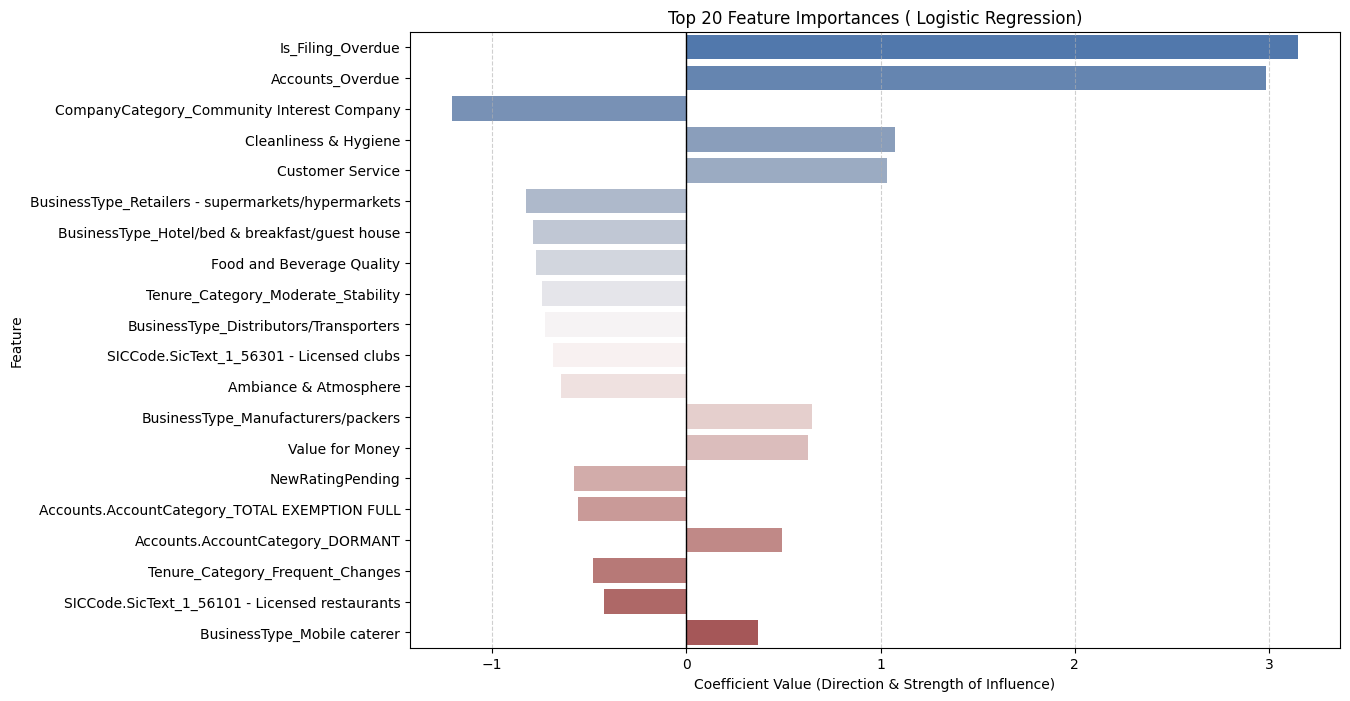

In [ ]:
def plot_feature_importance(model, feature_names,model_name):
    # 1. Extract coefficients (LogReg stores them in a nested array)
    importance = model.coef_[0]

    # 2. Create a DataFrame for analysis
    feat_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })

    # 3. Calculate absolute importance for sorting
    feat_df['Abs_Importance'] = feat_df['Importance'].abs()
    feat_df = feat_df.sort_values(by='Abs_Importance', ascending=False)

    # 4. Visualization
    plt.figure(figsize=(12, 8))
    # Using 'vlag' palette: Red usually indicates negative, Blue positive
    sns.barplot(
        x='Importance',
        y='Feature',
        data=feat_df.head(20),
        palette='vlag'
    )
    plt.axvline(0, color='black', lw=1) # Reference line at zero
    plt.title(f"Top 20 Feature Importances ( {model_name})")
    plt.xlabel('Coefficient Value (Direction & Strength of Influence)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

# Run the function
# Ensure 'X' is the DataFrame of features used for training
plot_feature_importance(model, X.columns,"Logistic Regression")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Unbalanced Stress Test Fit Analysis ---
TRAIN: Accuracy = 95.07%, ROC-AUC = 0.7561
TEST:  Accuracy = 95.09%, ROC-AUC = 0.7397
OVERFIT GAP (AUC): 0.0164

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4705
           1       1.00      0.01      0.02       245

    accuracy                           0.95      4950
   macro avg       0.98      0.50      0.50      4950
weighted avg       0.95      0.95      0.93      4950



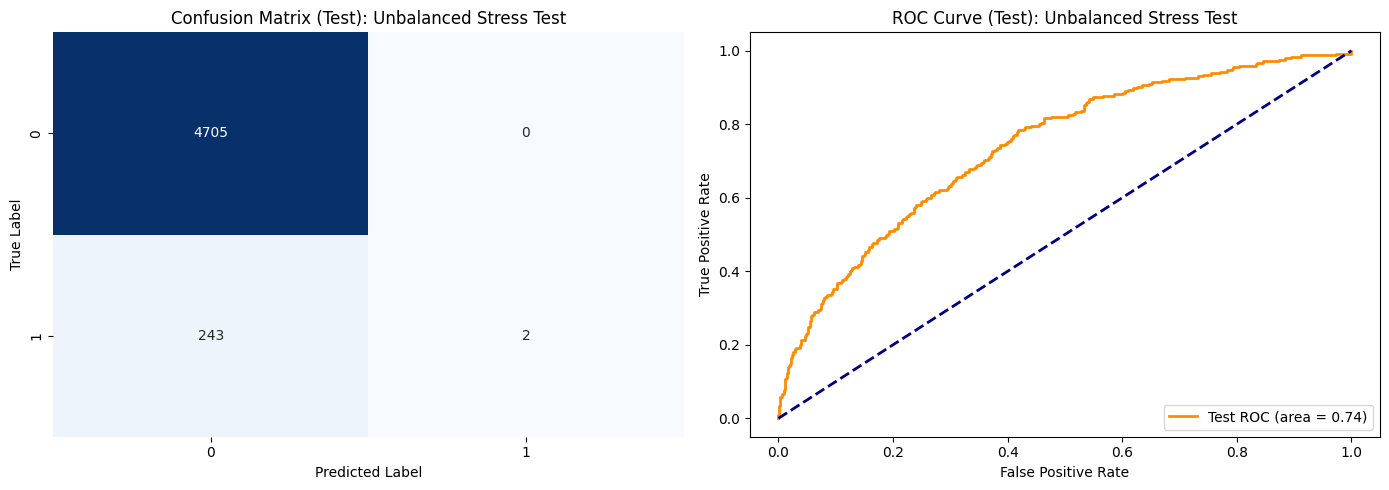

In [ ]:
# 1. Create a feature set WITHOUT the 'Overdue' flags
X_stress_test = X_final.drop(columns=[' CompanyNumber', 'Target Value', 'Is_Filing_Overdue', 'Accounts_Overdue'])

# 2. Re-split the data
X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
    X_stress_test, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Re-train with 'balanced' weights
model_unbalanced = LogisticRegression(max_iter=1000)
model_unbalanced.fit(X_train_st, y_train_st)

# 3. Evaluate
evaluate_model(model_unbalanced, X_train_st, y_train_st, X_test_st, y_test_st, name="Unbalanced Stress Test")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Balanced Stress Test Fit Analysis ---
TRAIN: Accuracy = 65.38%, ROC-AUC = 0.7596
TEST:  Accuracy = 66.08%, ROC-AUC = 0.7420
OVERFIT GAP (AUC): 0.0176

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.66      0.79      4705
           1       0.09      0.68      0.17       245

    accuracy                           0.66      4950
   macro avg       0.53      0.67      0.48      4950
weighted avg       0.93      0.66      0.76      4950



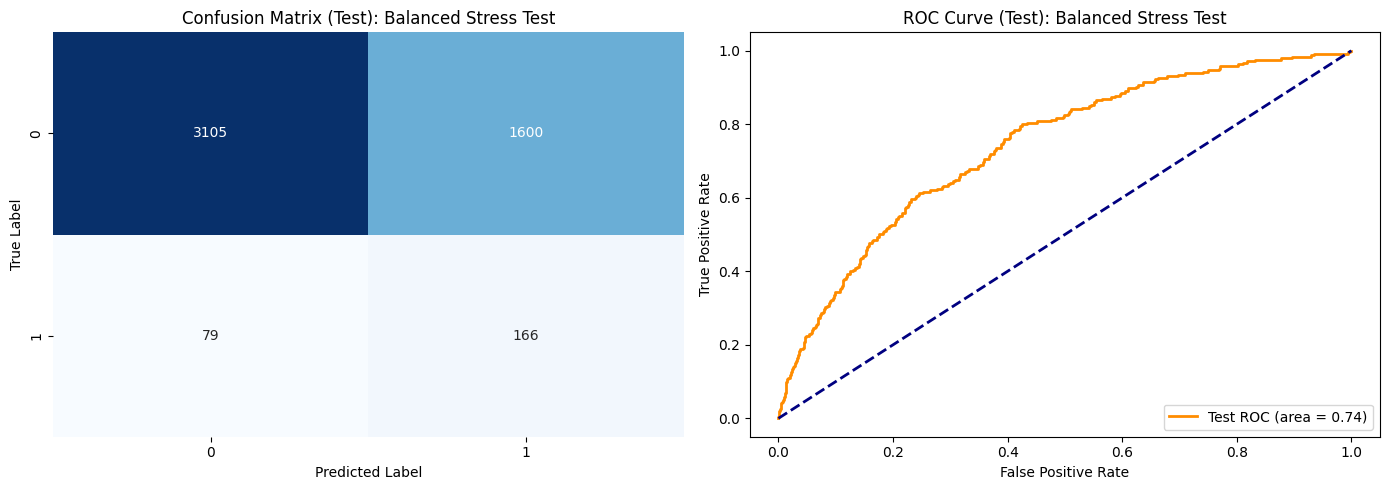

In [ ]:
# 1. Initialize with 'balanced' weights
model_balanced_stress = LogisticRegression(max_iter=1000, class_weight='balanced')

# 2. Fit on the Stress Test data (No Overdue flags)
model_balanced_stress.fit(X_train_st, y_train_st)

# 3. Evaluate using our function
evaluate_model(model_balanced_stress, X_train_st, y_train_st, X_test_st, y_test_st, name="Balanced Stress Test")

/tmp/ipykernel_15315/3601008788.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


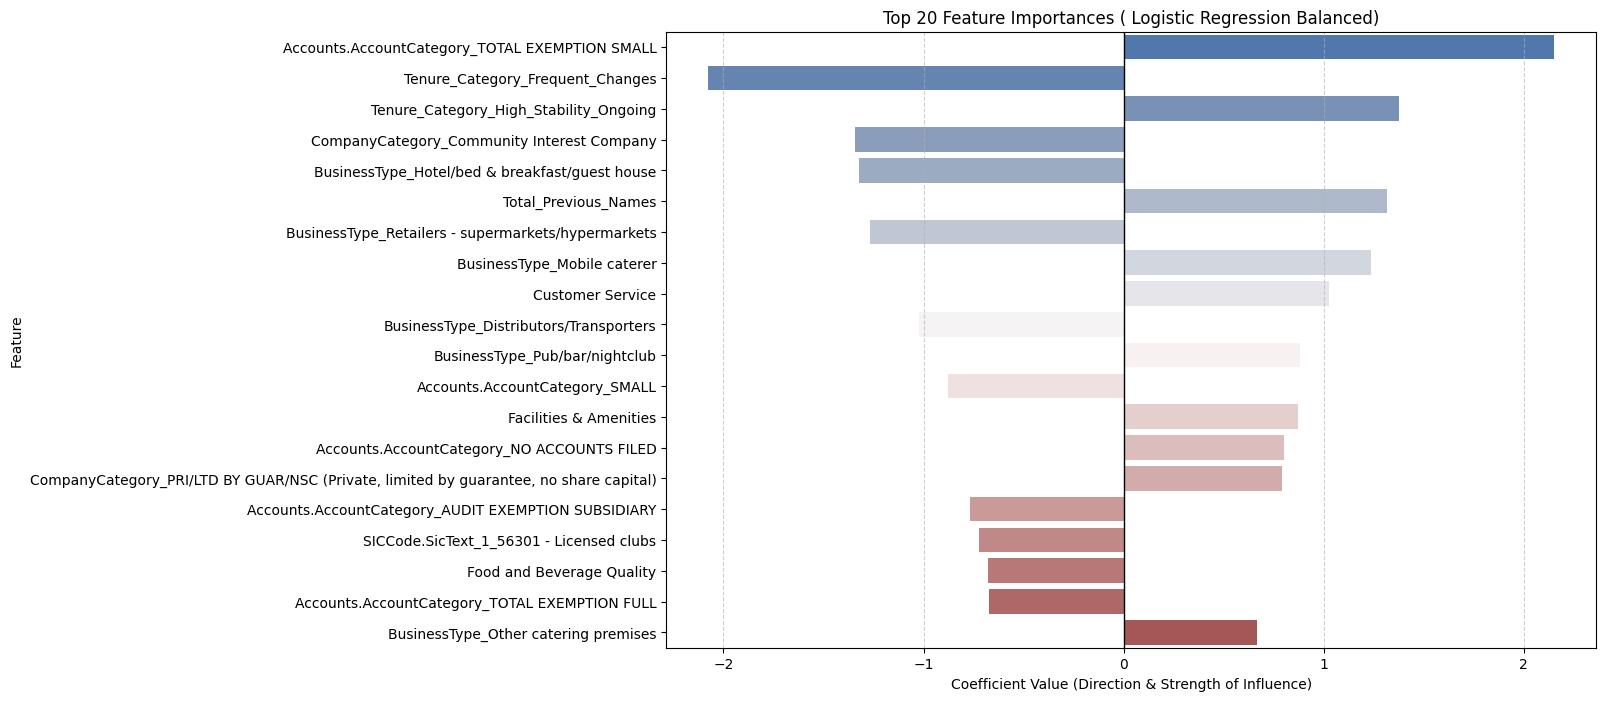

In [ ]:
# Run the importance plot on this balanced stress model
plot_feature_importance(model_balanced_stress, X_stress_test.columns,"Logistic Regression Balanced")

--- RF Unbalanced Stress Test Fit Analysis ---
TRAIN: Accuracy = 95.42%, ROC-AUC = 0.9890
TEST:  Accuracy = 95.07%, ROC-AUC = 0.7640
OVERFIT GAP (AUC): 0.2250

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4705
           1       1.00      0.00      0.01       245

    accuracy                           0.95      4950
   macro avg       0.98      0.50      0.49      4950
weighted avg       0.95      0.95      0.93      4950



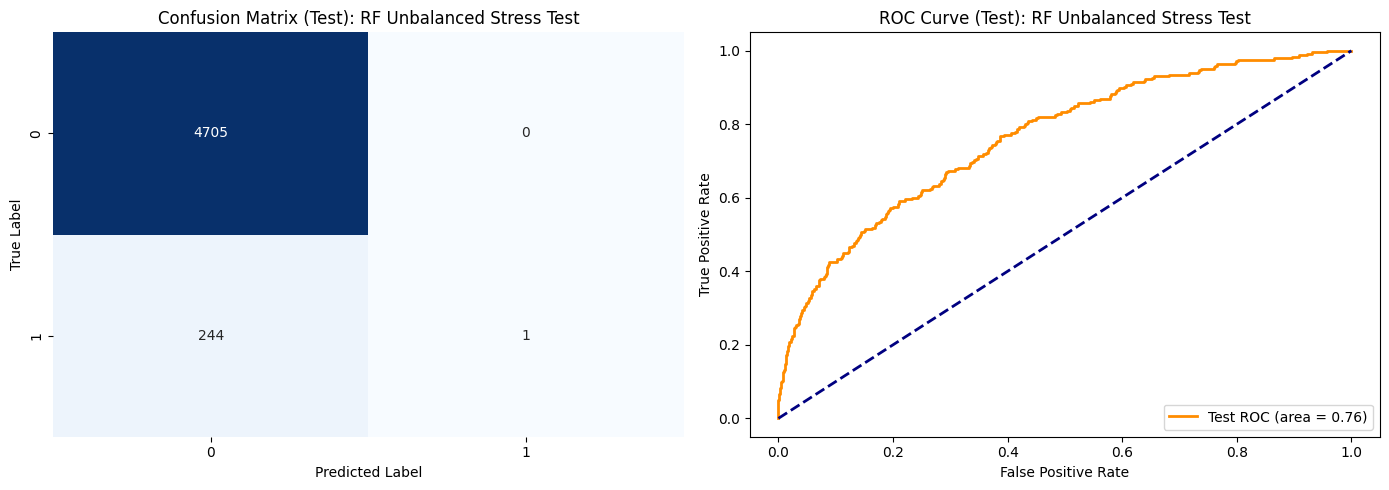

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize without balancing
# We set a max_depth to keep it from just memorizing the training set
rf_unbalanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight=None, # The 'Natural' approach
    random_state=42
)

# 2. Fit on the Stress Test data
rf_unbalanced.fit(X_train_st, y_train_st)

# 3. Evaluate
# Using the function that compares Train vs Test
evaluate_model(rf_unbalanced, X_train_st, y_train_st, X_test_st, y_test_st, name="RF Unbalanced Stress Test")

--- RF + SMOTE/Under-sampling Fit Analysis ---
TRAIN: Accuracy = 96.69%, ROC-AUC = 0.9750
TEST:  Accuracy = 94.97%, ROC-AUC = 0.7727
OVERFIT GAP (AUC): 0.2024

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      4705
           1       0.46      0.10      0.16       245

    accuracy                           0.95      4950
   macro avg       0.71      0.55      0.57      4950
weighted avg       0.93      0.95      0.93      4950



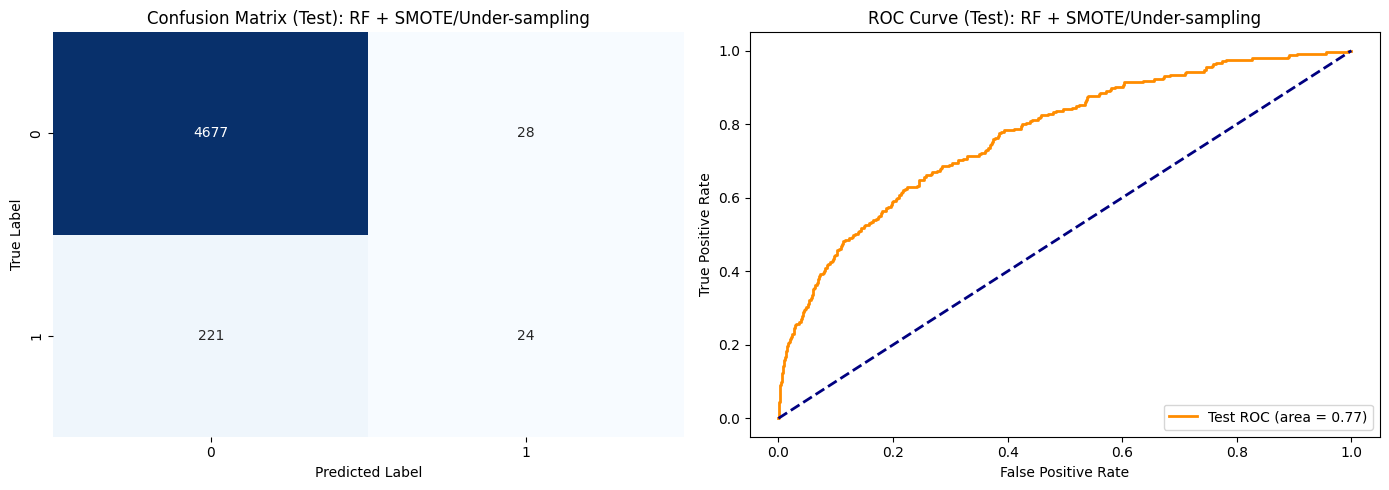

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# 1. Define the resampling strategy
# over: Increase the '1's to 1,000 rows
# under: Decrease the '0's to 2,000 rows
over = SMOTE(sampling_strategy=0.2, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

# 2. Create the Pipeline
# We include the forest inside the pipeline to ensure we only resample the TRAIN data
# (Never resample your Test data, or your scores will be fake!)
steps = [('o', over), ('u', under), ('model', rf_unbalanced)]
pipeline = Pipeline(steps=steps)

# 3. Fit the pipeline on the Stress Test data
pipeline.fit(X_train_st, y_train_st)

# 4. Evaluate
evaluate_model(pipeline, X_train_st, y_train_st, X_test_st, y_test_st, name="RF + SMOTE/Under-sampling")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- LogReg + Resampling (Stress Test) Fit Analysis ---
TRAIN: Accuracy = 81.47%, ROC-AUC = 0.7546
TEST:  Accuracy = 81.96%, ROC-AUC = 0.7415
OVERFIT GAP (AUC): 0.0131

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      4705
           1       0.13      0.47      0.21       245

    accuracy                           0.82      4950
   macro avg       0.55      0.66      0.55      4950
weighted avg       0.93      0.82      0.86      4950



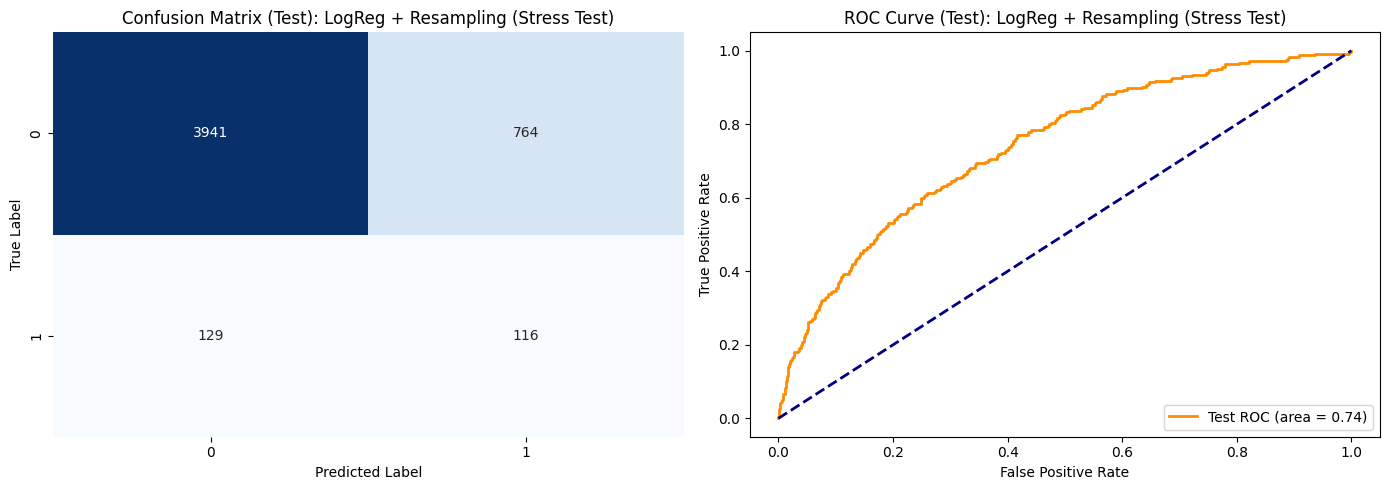

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. Setup the Resampling Strategy
# We'll boost targets to 1,500 and trim safe businesses to 3,000
over = SMOTE(sampling_strategy=0.3, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.6, random_state=42)

# 2. Create the Pipeline with Logistic Regression
# We use max_iter=1000 to ensure the model converges on the new data
log_reg_resampled = LogisticRegression(max_iter=1000)

pipeline_lr = Pipeline(steps=[
    ('o', over),
    ('u', under),
    ('model', log_reg_resampled)
])

# 3. Fit on the Stress Test data (Still no Overdue flags!)
pipeline_lr.fit(X_train_st, y_train_st)

# 4. Evaluate
evaluate_model(pipeline_lr, X_train_st, y_train_st, X_test_st, y_test_st, name="LogReg + Resampling (Stress Test)")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- LogReg SMOTE-Tomek (No Balance) Fit Analysis ---
TRAIN: Accuracy = 89.48%, ROC-AUC = 0.7549
TEST:  Accuracy = 89.15%, ROC-AUC = 0.7406
OVERFIT GAP (AUC): 0.0143

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      4705
           1       0.18      0.33      0.23       245

    accuracy                           0.89      4950
   macro avg       0.57      0.63      0.59      4950
weighted avg       0.92      0.89      0.91      4950



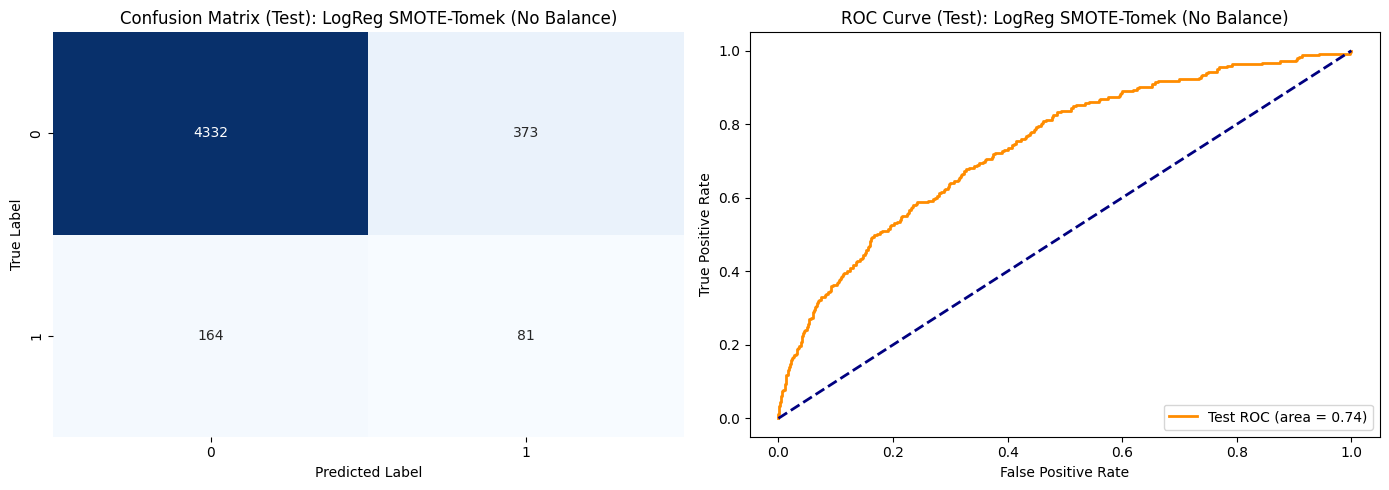

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline

# 1. Define the Sampling Strategy
# We'll boost the targets but keep the model 'unbalanced' to force precision
over = SMOTE(sampling_strategy=0.4, random_state=42)
tomek = TomekLinks()

# 2. Build the Pipeline
# Note: LogisticRegression(class_weight=None) is the default
pipeline_hybrid = Pipeline(steps=[
    ('smote', over),
    ('tomek', tomek),
    ('model', LogisticRegression(max_iter=1000))
])

# 3. Fit on the Stress Test (No Overdue flags)
pipeline_hybrid.fit(X_train_st, y_train_st)

# 4. Evaluate
evaluate_model(pipeline_hybrid, X_train_st, y_train_st, X_test_st, y_test_st, name="LogReg SMOTE-Tomek (No Balance)")

In [ ]:
len(X_train_st)

19798

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- LogReg SMOTE(No Balance) Fit Analysis ---
TRAIN: Accuracy = 89.61%, ROC-AUC = 0.7548
TEST:  Accuracy = 89.27%, ROC-AUC = 0.7403
OVERFIT GAP (AUC): 0.0144

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      4705
           1       0.18      0.33      0.24       245

    accuracy                           0.89      4950
   macro avg       0.57      0.63      0.59      4950
weighted avg       0.93      0.89      0.91      4950



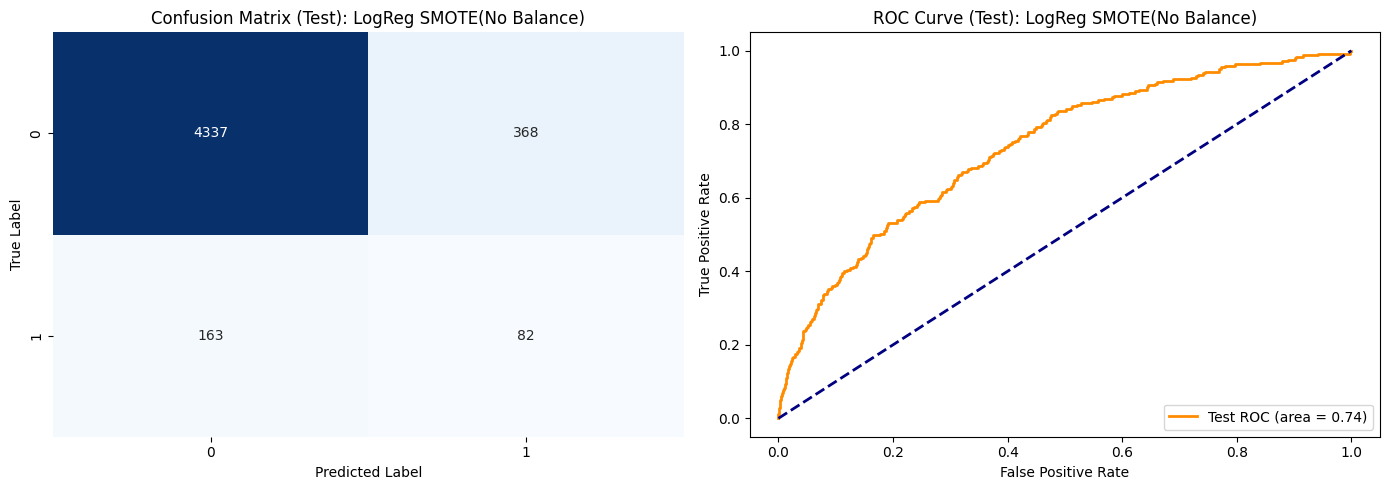

In [ ]:
pipeline_hybrid = Pipeline(steps=[
    ('smote', over),
    ('model', LogisticRegression(max_iter=1000))
])

# 3. Fit on the Stress Test (No Overdue flags)
pipeline_hybrid.fit(X_train_st, y_train_st)

# 4. Evaluate
evaluate_model(pipeline_hybrid, X_train_st, y_train_st, X_test_st, y_test_st, name="LogReg SMOTE(No Balance)")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:41:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:46: You have manually specified the `updater` parameter. The `tree_method` parameter will be ignored. Incorrect sequence of updaters will produce undefined behavior. For common uses, we recommend using `tree_method` parameter instead.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:41:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [19:41:26] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential sol

--- XGBoost + SMOTE Fit Analysis ---
TRAIN: Accuracy = 99.97%, ROC-AUC = 1.0000
TEST:  Accuracy = 94.99%, ROC-AUC = 0.7319
OVERFIT GAP (AUC): 0.2681

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      4705
           1       0.48      0.16      0.24       245

    accuracy                           0.95      4950
   macro avg       0.72      0.58      0.61      4950
weighted avg       0.93      0.95      0.94      4950



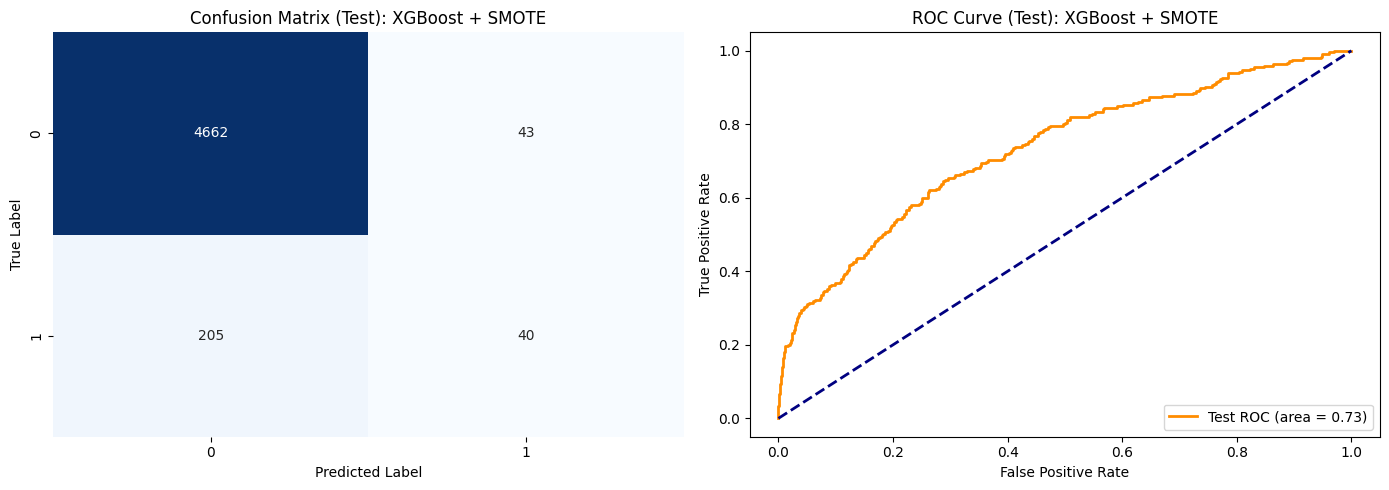

In [ ]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline

# 2. XGBoost Setup
# We don't use 'balanced' weights here; we let the Gradient Boosting find the depth.
xgb_aggressive = XGBClassifier(
    tree_method='hist',       # Use the GPU
    predictor='gpu_predictor',    # Predict on GPU too
    n_estimators=1200,            # High tree count
    max_depth=6,                 # Deep enough to find complex 'vibe' patterns
    learning_rate=0.04,           # Low rate to keep 1000 trees stable
    scale_pos_weight=4,
    gamma=0.2,                    # Minimum loss reduction to split
    subsample=0.9,                # Train each tree on 90% of data (adds variety)
    colsample_bytree=0.9,         # Use 80% of your 77 features per tree
    updater = 'grow_gpu_hist',
    random_state=42,
    eval_metric='aucpr',
    device = 'cuda' # Target Precision-Recall Area specifically
)

# 3. Create the 'Stress Test' Pipeline (No Overdue Flags)
pipeline_xgb = Pipeline(steps=[
    ('smote', over),
    ('model', xgb_aggressive)
])

# 4. Fit and Evaluate
pipeline_xgb.fit(X_train_st, y_train_st)
evaluate_model(pipeline_xgb, X_train_st, y_train_st, X_test_st, y_test_st, name="XGBoost + SMOTE")

/tmp/ipykernel_15315/947887607.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df.head(20), palette='viridis')


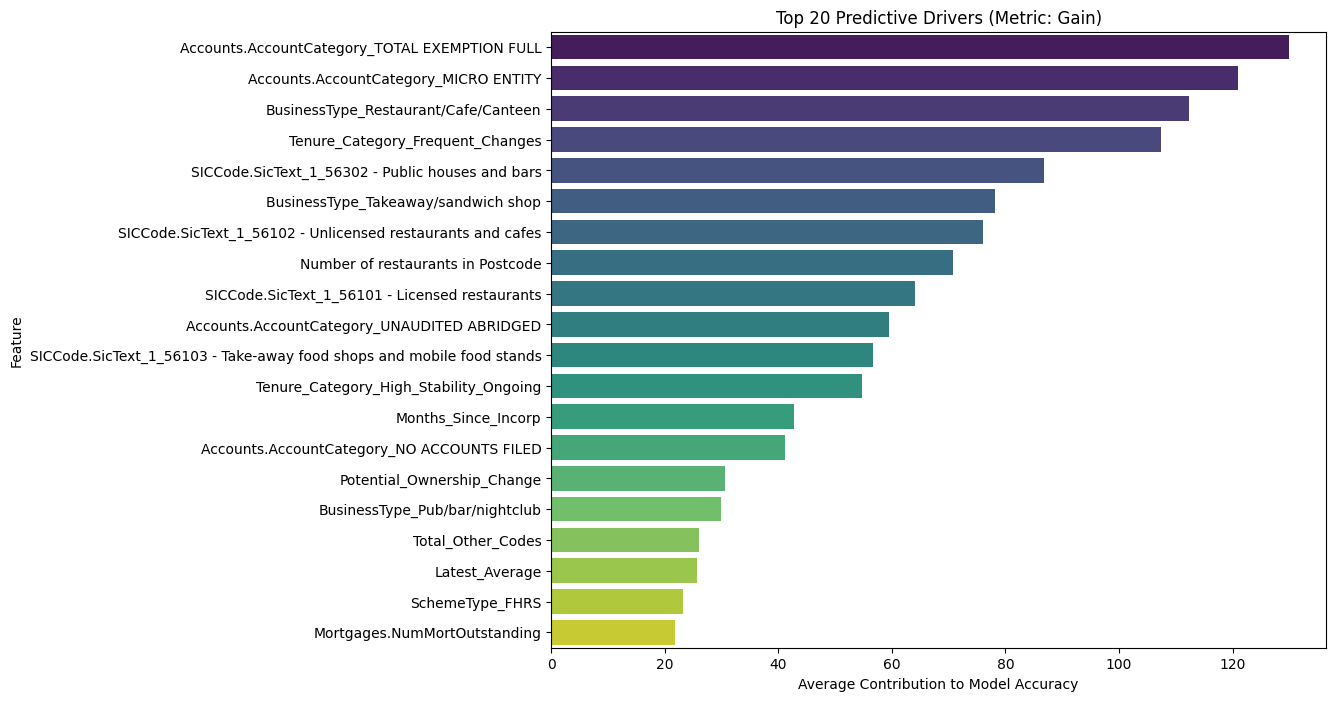

In [ ]:
importance_type = 'gain'
feat_importance = xgb_aggressive.get_booster().get_score(importance_type=importance_type)

# Convert to DataFrame for plotting
feat_df = pd.DataFrame({
    'Feature': feat_importance.keys(),
    'Importance': feat_importance.values()
}).sort_values(by='Importance', ascending=False)

# Plot the top 15
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(20), palette='viridis')
plt.title(f'Top 20 Predictive Drivers (Metric: {importance_type.capitalize()})')
plt.xlabel('Average Contribution to Model Accuracy')
plt.show()

In [ ]:
!pip install tensorflow

In [ ]:
!pip install scikeras

--- NN + SMOTE (Fixed) Fit Analysis ---
TRAIN: Accuracy = 88.90%, ROC-AUC = 0.9509
TEST:  Accuracy = 89.11%, ROC-AUC = 0.7093
OVERFIT GAP (AUC): 0.2416

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      4705
           1       0.17      0.31      0.22       245

    accuracy                           0.89      4950
   macro avg       0.57      0.62      0.58      4950
weighted avg       0.92      0.89      0.91      4950



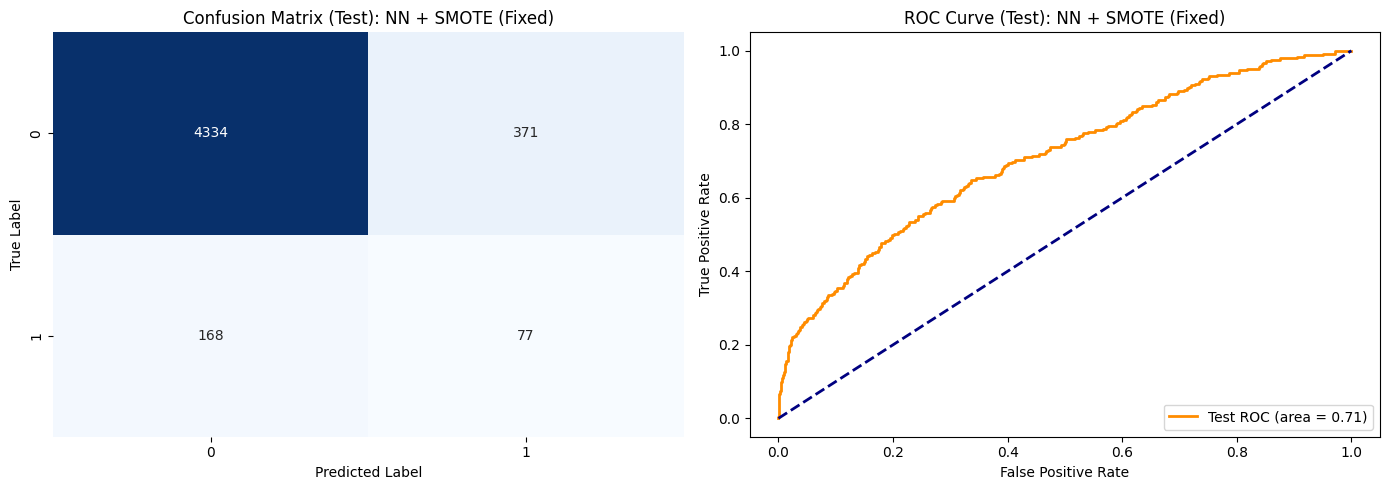

In [ ]:
from scikeras.wrappers import KerasClassifier
from imblearn.pipeline import Pipeline
from tensorflow.keras import layers, models
from imblearn.over_sampling import SMOTE # Import SMOTE explicitly

# 1. Architecture definition (matches your 77-feature input)
def create_nn_model():
    model = models.Sequential([
        layers.Input(shape=(X_train_st.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(), # Vital for A100 gradient stability
        layers.Dropout(0.3),         # Prevents 'memorizing' the 95% majority class
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid') # Binary probability output
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

# --- MODIFIED PART: Apply SMOTE separately and then train KerasClassifier ---

# 2. Apply SMOTE separately to the training data
smote_sampler = SMOTE(sampling_strategy=0.4, random_state=42) # Re-using the 'over' strategy
X_train_resampled, y_train_resampled = smote_sampler.fit_resample(X_train_st, y_train_st)

# 3. Instantiate KerasClassifier directly (not inside imblearn Pipeline)
keras_nn_model = KerasClassifier(
    model=create_nn_model,
    epochs=100,      # High epoch count to let the NN converge
    batch_size=128,  # Efficient batch size for A100 memory
    verbose=0
)

# 4. Fit the KerasClassifier on the resampled training data
keras_nn_model.fit(X_train_resampled, y_train_resampled)

# 5. Evaluate the fitted KerasClassifier model
# Pass the fitted keras_nn_model and the resampled training data to evaluate_model
evaluate_model(keras_nn_model, X_train_resampled, y_train_resampled, X_test_st, y_test_st, name="NN + SMOTE (Fixed)")